### **Assignment-01 : SMS Spam Classification**
### **Nisith Ranjan Hazra (MDS202427)**
#### **Data Preparation**

In this notebook, we will build the data pipeline for an SMS spam classification task. This includes loading the dataset, performing exploratory data analysis (EDA) to understand its structure and patterns, and finally dividing the data into training, validation, and test sets for model development and evaluation.

#### **Required package installation**

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn nltk


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
#### Load the library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from collections import Counter
import os
import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


#### **Load Data**

In [4]:
#### Loading the dataset
df = pd.read_csv('dataset/SMSSpamCollection', sep='\t', header=None, names=['label', 'message'], encoding='latin-1')
print(f"Total messages: {len(df)}")
df.head(10)

Total messages: 5572


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


#### **Exploratory Data Analysis (EDA)**

#### **Class Distribution graph -- spam vs ham**

In [5]:
print(df['label'].value_counts()) #### the number of spam and ham 
print(f"\nSpam percentage: {(df['label'] == 'spam').mean() * 100:.2f}%") 

label
ham     4825
spam     747
Name: count, dtype: int64

Spam percentage: 13.41%


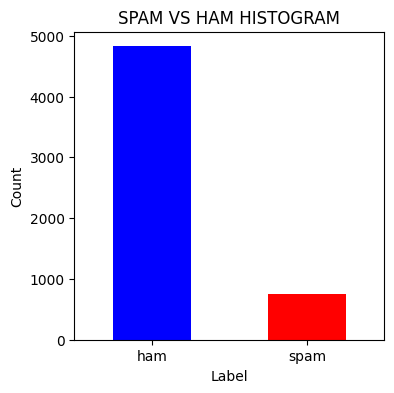

In [6]:
#### Plot the  Histogram of spam vs ham
plt.figure(figsize=(4, 4))
df['label'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('SPAM VS HAM HISTOGRAM')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

####  **SMS Length Distribution**

In [7]:
df['msg_length'] = df['message'].apply(len) #### Number of characters in each message
print("Message length stats:")
print(df['msg_length'].describe())

Message length stats:
count    5572.000000
mean       80.616296
std        60.015593
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: msg_length, dtype: float64


#### **SMS Length Distribution by Class**

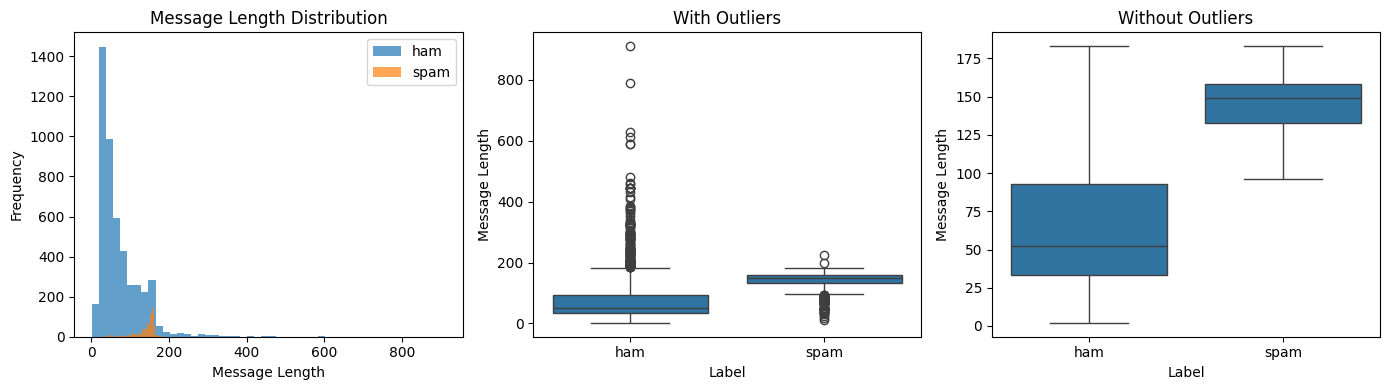


Message length by class:
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.558964  58.459702   2.0   33.0   52.0   93.0  910.0
spam    747.0  139.119143  28.998900  13.0  133.0  149.0  158.0  224.0


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(df[df['label'] == 'ham']['msg_length'], bins=50, alpha=0.7, label='ham')
axes[0].hist(df[df['label'] == 'spam']['msg_length'], bins=50, alpha=0.7, label='spam')
axes[0].set_xlabel('Message Length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Message Length Distribution')
axes[0].legend()
sns.boxplot(data=df, x='label', y='msg_length', ax=axes[1])
axes[1].set_title('With Outliers')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Message Length')
sns.boxplot(data=df, x='label', y='msg_length', ax=axes[2], showfliers=False)
axes[2].set_title('Without Outliers')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Message Length')
plt.tight_layout()
plt.show()
print("\nMessage length by class:")
print(df.groupby('label')['msg_length'].describe())

#### **Frequent Words in Spam vs Ham(without Stopwords)**

In [9]:
def get_words(text):
    """Extract words from text after removing stopwords"""
    text = text.lower()
    words = re.findall(r'\b[a-z]+\b', text)
    
    words = [w for w in words if w not in stop_words] # remove stopwords
    
    return words
spam_words = []
for msg in df[df['label'] == 'spam']['message']:
    spam_words.extend(get_words(msg))

ham_words = []
for msg in df[df['label'] == 'ham']['message']:
    ham_words.extend(get_words(msg))
print(f"Total words in spam (after removing stopwords): {len(spam_words)}")
print(f"Total words in ham (after removing stopwords): {len(ham_words)}")

Total words in spam (after removing stopwords): 10396
Total words in ham (after removing stopwords): 38333


In [10]:
##### top 20 words in spam and ham
spam_common = Counter(spam_words).most_common(20)
ham_common = Counter(ham_words).most_common(20)

print("Most common words in SPAM:")
for word, count in spam_common:
    print(f"  {word}: {count}")

print("\nMost common words in HAM:")
for word, count in ham_common:
    print(f"  {word}: {count}")

Most common words in SPAM:
  call: 355
  free: 224
  u: 173
  txt: 163
  ur: 144
  mobile: 127
  text: 125
  stop: 123
  claim: 113
  reply: 104
  www: 98
  prize: 93
  get: 86
  cash: 76
  uk: 74
  send: 71
  new: 69
  nokia: 67
  win: 64
  urgent: 63

Most common words in HAM:
  u: 1033
  gt: 318
  lt: 316
  get: 305
  ok: 288
  go: 252
  ur: 247
  call: 238
  know: 237
  good: 235
  like: 234
  got: 233
  come: 230
  day: 212
  love: 205
  time: 202
  going: 169
  one: 168
  home: 165
  want: 165


### Preprocessing

In [11]:
#### convert labels to binary - spam=1, ham=0
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

#### Check the missing values 
print("Missing values:")
print(df.isnull().sum())

df.head()

Missing values:
label         0
message       0
msg_length    0
label_num     0
dtype: int64


,label,message,msg_length,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",111,0
1,ham,Ok lar... Joking wif u oni...,29,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,1
3,ham,U dun say so early hor... U c already then say...,49,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,0


#### **Training Split/Validation Split/Test Split**

Splitting the data into 80% train, 10% validation, 10% test. Using stratified split to keep the same ratio of spam/ham in each set.

In [12]:
#### first split into train (80%) and temporay (20%)
train_df,temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

####then split temp into validation (05%) and test (10%)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"Train size: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation size: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test size: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

Train size: 4457 (80.0%)
Validation size: 557 (10.0%)
Test size: 558 (10.0%)


#### Verify Class Distribution in each set(Stratified Split)

In [13]:
print("Spam percentage in each set:")
print(f"  Train: {(train_df['label'] == 'spam').mean() * 100:.2f}%")
print(f"  Validation: {(val_df['label'] == 'spam').mean() * 100:.2f}%")
print(f"  Test: {(test_df['label'] == 'spam').mean() * 100:.2f}%")

Spam percentage in each set:
  Train: 13.42%
  Validation: 13.29%
  Test: 13.44%


In [14]:
#### save the data to csv
train_df[['label', 'message']].to_csv('dataset/train_data.csv', index=False)
val_df[['label', 'message']].to_csv('dataset/validation_data.csv', index=False)
test_df[['label', 'message']].to_csv('dataset/test_data.csv', index=False)
